# Load dataset from DB

In [81]:
import sys
import os

sys.path.append("../backend")

from extract_data import get_data_from_db

# 로컬 테스트를 위해 부모 디렉토리의 .env 파일을 찾아 수동으로 환경변수 세팅
env_path = 'C:\dev\SKN27-2nd-2TEAM\.env'
if os.path.exists(env_path):
    with open(env_path, 'r') as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                key, value = line.strip().split('=', 1)
                os.environ[key] = value

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\2657942140.py:9: SyntaxWarning: invalid escape sequence '\d'
  env_path = 'C:\dev\SKN27-2nd-2TEAM\.env'


In [82]:
user_df = get_data_from_db("SELECT * FROM users")
movie_df = get_data_from_db("SELECT * FROM movies")
rec_df = get_data_from_db("SELECT * FROM recommendation_logs")
review_df = get_data_from_db("SELECT * FROM reviews")
watch_df = get_data_from_db("SELECT * FROM watch_history")
search_df = get_data_from_db("SELECT * FROM search_logs")

DB 연결 성공
DB 연결 성공
DB 연결 성공
DB 연결 성공
DB 연결 성공
DB 연결 성공


# 데이터 전처리 및 EDA

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme()

#### Train / Test split

In [84]:
from sklearn.model_selection import train_test_split

user_df['churned'] = 1 - user_df['is_active']
y = user_df['churned']
X = user_df.drop(['is_active', 'churned'], axis=1)

drop_cols = ['user_id', 'email', 'first_name', 'last_name', 'city', 'created_at']
X = X.drop(drop_cols, axis=1)
X.head()

,age,gender,country,state_province,subscription_plan,subscription_start_date,monthly_spend,primary_device,household_size
0,43.0,Male,USA,Massachusetts,Basic,2024-04-08,36.06,Laptop,1.0
1,38.0,Male,USA,Texas,Premium+,2024-05-24,14.59,Desktop,2.0
2,32.0,Female,USA,Michigan,Standard,2023-09-22,11.71,Desktop,3.0
3,11.0,Male,USA,Ohio,Standard,2024-08-21,28.56,Laptop,2.0
4,21.0,Female,USA,Arizona,Standard,2024-10-28,9.54,Desktop,6.0


In [85]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
train = pd.concat([X_tr, y_tr], axis=1)
test = pd.concat([X_te, y_te], axis=1)

X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((8000, 9), (2000, 9), (8000,), (2000,))

#### 타겟값 분포 확인 -> 데이터 불균형 존재

<Axes: xlabel='churned', ylabel='count'>

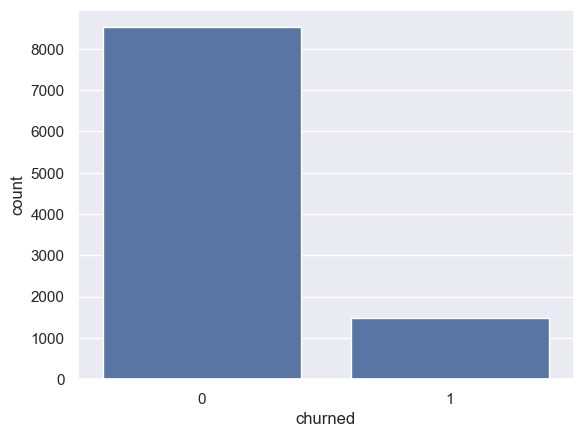

In [86]:
sns.countplot(user_df, x='churned')

#### age 분포
- 평균과 중간값이 모두 35
- 나이가 음수인 데이터와 지나치게 높은 데이터 존재
- 범위를 0에서 70으로 제한

count    7031.000000
mean       34.982933
std        12.518424
min        -7.000000
25%        27.000000
50%        35.000000
75%        43.000000
max       109.000000
Name: age, dtype: float64


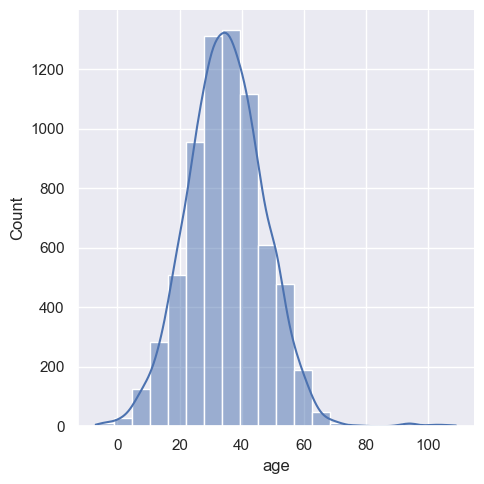

In [87]:
print(train['age'].describe())
sns.displot(data=train, x='age', bins=20, kde=True)

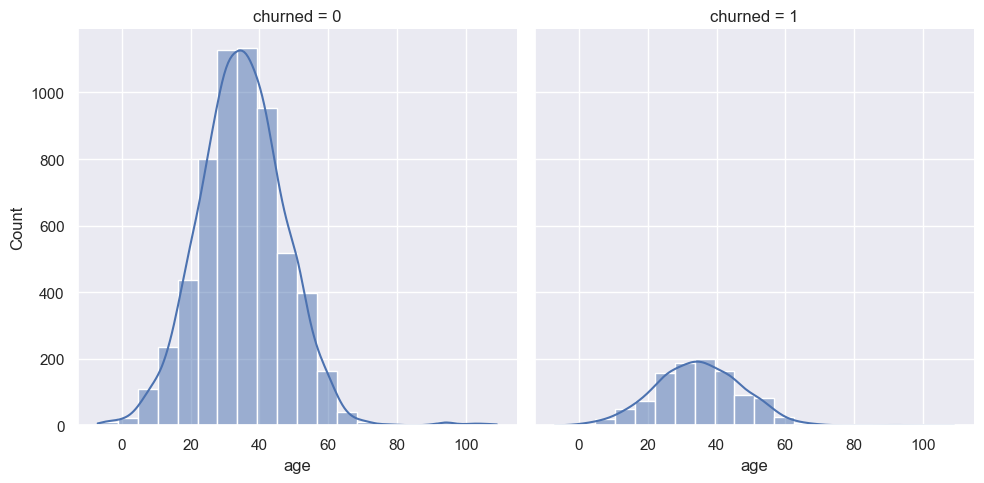

In [88]:
sns.displot(data=train, x='age', col='churned', bins=20, multiple='dodge', kde=True)

#### gender 분포
- 남성, 여성 외에 성별을 입력하지 않은 상태 존재
- 각 성별군마다 churned 상의 큰 차이는 확인하기 어려움

gender
Female               3382
Male                 3274
Other                 368
Prefer not to say     356
Name: count, dtype: int64


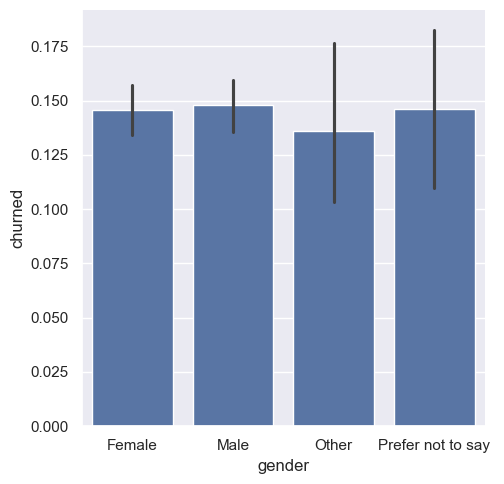

In [89]:
print(train['gender'].value_counts())
sns.catplot(data=train, x='gender', y='churned', kind='bar')

#### country & state_province 분포
- 2개 카테고리(미국, 캐나다) 간의 눈에 띄는 차이는 보이지 않음
- state_province: 30개 주가 명목형으로 기록되어 있고, 주마다 churned의 약간씩 차이 있음

country
USA       5576
Canada    2424
Name: count, dtype: int64


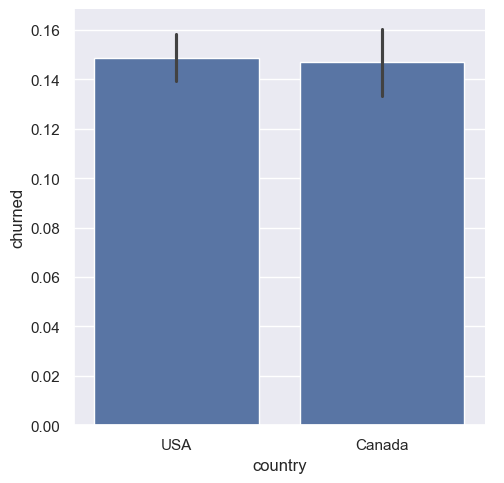

In [90]:
print(train.country.value_counts())
sns.catplot(data=train, x='country', y='churned', kind='bar')

30


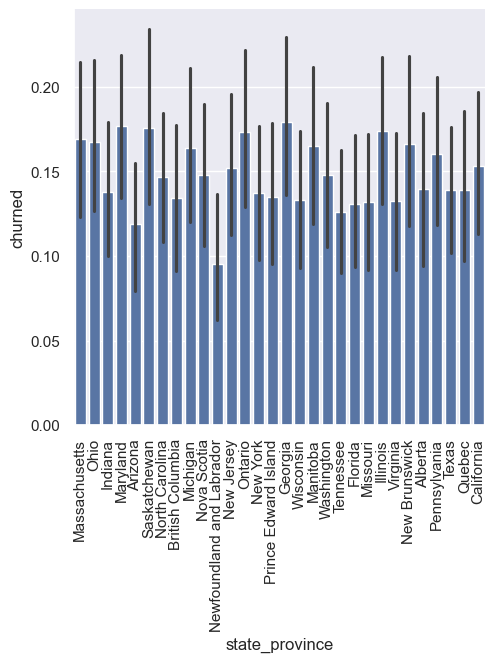

In [91]:
print(train.state_province.nunique())
sns.catplot(data=train, x='state_province', y='churned', kind='bar')
plt.xticks(rotation=90)
plt.show()

#### subscription & monthly_spend 분포
- subscription_plan: Basic, Standard, Premium, Premium+ 의 4가지 플랜
- monthly_spend: 매우 불균형한 분포 -> 이상치 처리 없이는 두 변수 사이의 관계를 확인하기 어려움

subscription_plan
Standard    2811
Premium     2778
Basic       1594
Premium+     817
Name: count, dtype: int64


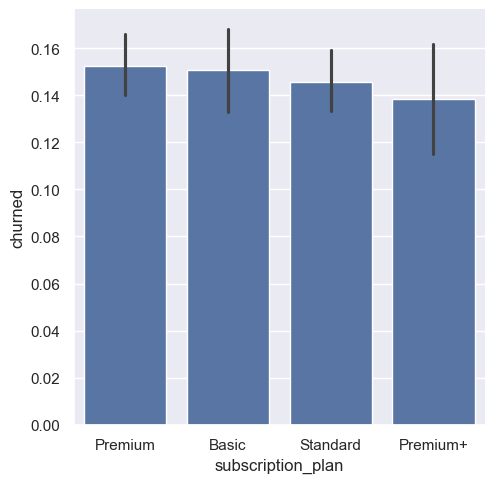

In [92]:
print(train.subscription_plan.value_counts())

sns.catplot(data=train, x='subscription_plan', y='churned', kind='bar')

count    7205.000000
mean       22.480046
std        68.191251
min         0.110000
25%         7.780000
50%        13.590000
75%        21.670000
max       997.800000
Name: monthly_spend, dtype: float64


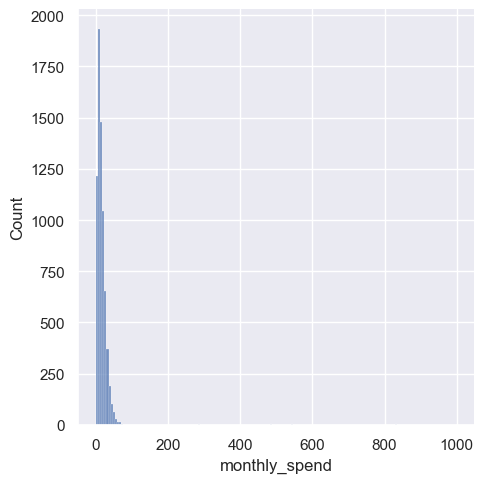

In [93]:
print(train.monthly_spend.describe())
sns.displot(data=train, x='monthly_spend')

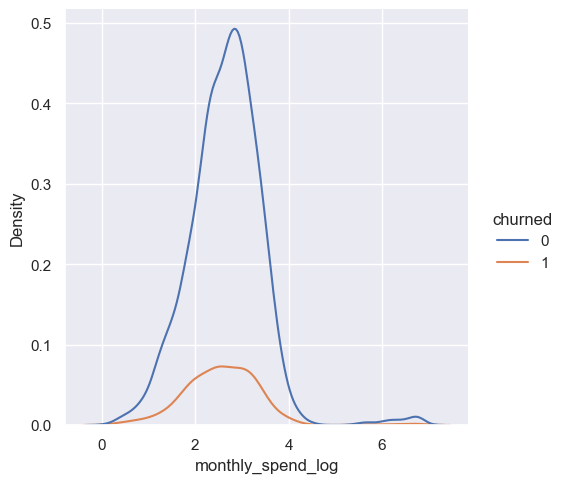

In [94]:
train['monthly_spend_log'] = np.log1p(train['monthly_spend'])
sns.displot(data=train, x='monthly_spend_log', hue='churned', kind='kde')

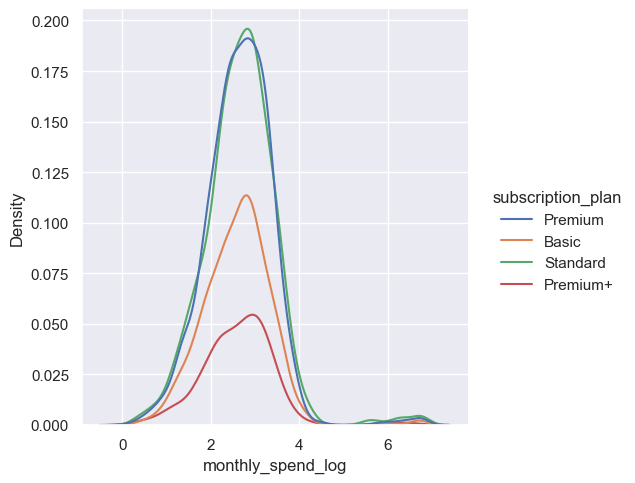

In [95]:
sns.displot(data=train, x='monthly_spend_log', hue='subscription_plan', kind='kde')

#### device & household_size 분포
- primary_device: 'Mobile' 'Desktop' 'Smart TV' 'Laptop' 'Tablet' 'Gaming Console' -> 6개 카테고리
- household_size: 가구 수 정보; 순서 동일

primary_device
Desktop           1408
Laptop            1340
Tablet            1339
Smart TV          1329
Gaming Console    1295
Mobile            1289
Name: count, dtype: int64


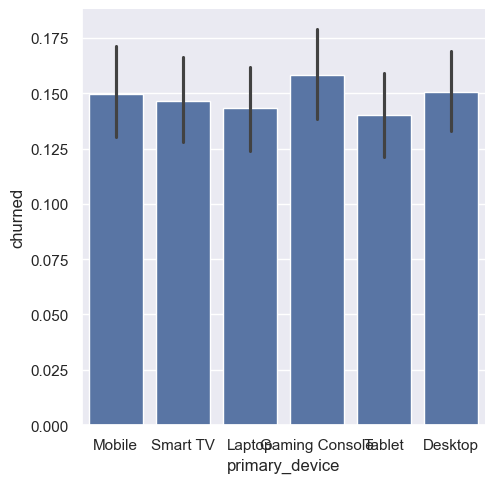

In [96]:
print(train.primary_device.value_counts())
sns.catplot(data=train, x='primary_device', y='churned', kind='bar')

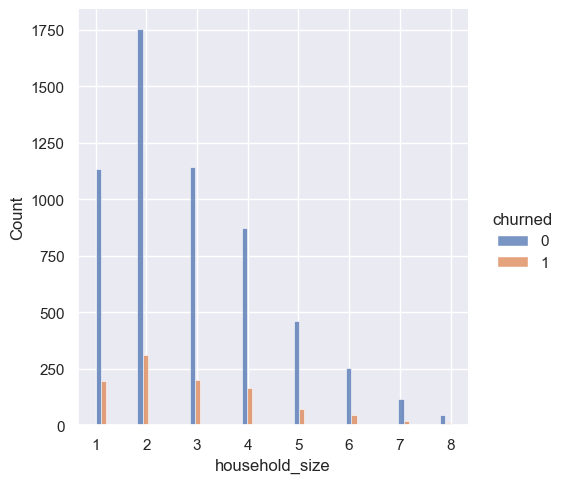

In [97]:
sns.displot(data=train, x='household_size', hue='churned', multiple='dodge')

### 이상치 처리

#### age -> 제거

               age  monthly_spend  household_size      churned  \
count  6769.000000    6089.000000     5738.000000  6769.000000   
mean     34.947850      21.755898        2.854479     0.151130   
std      10.934339      64.489637        1.554960     0.358202   
min      10.000000       0.110000        1.000000     0.000000   
25%      27.000000       7.680000        2.000000     0.000000   
50%      35.000000      13.480000        2.000000     0.000000   
75%      43.000000      21.440000        4.000000     0.000000   
max      60.000000     997.800000        8.000000     1.000000   

       monthly_spend_log  
count        6089.000000  
mean            2.634642  
std             0.789058  
min             0.104360  
25%             2.161022  
50%             2.672768  
75%             3.110845  
max             6.906555  


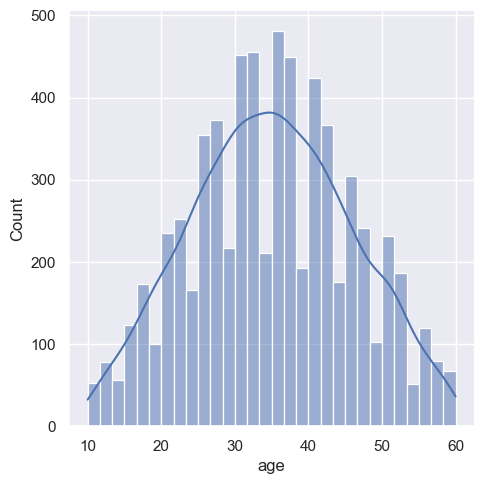

In [98]:
# age
age_mean = train['age'].mean()
age_std = train['age'].std()
train = train[(train['age'] >= age_mean - 2 * age_std) & (train['age'] <= age_mean + 2 * age_std)]
test = test[(test['age'] >= age_mean - 2 * age_std) & (test['age'] <= age_mean + 2 * age_std)]
print(train.describe())

sns.displot(data=train, x='age', kde=True)

## 결측치 처리

In [99]:
round(train.isnull().sum() / len(train), 3) * 100

age                         0.0
gender                      7.8
country                     0.0
state_province              0.0
subscription_plan           0.0
subscription_start_date     0.0
monthly_spend              10.0
primary_device              0.0
household_size             15.2
churned                     0.0
monthly_spend_log          10.0
dtype: float64

subscription_plan
Standard    2373
Premium     2366
Basic       1343
Premium+     687
Name: count, dtype: int64


C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\2694088436.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['gender'] = train['gender'].map(lambda x: proc_gender(x))


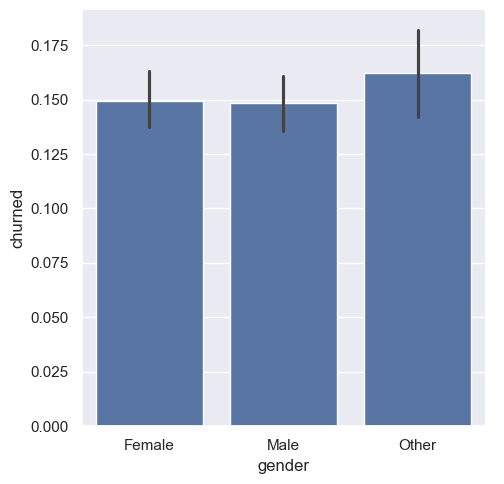

In [100]:
# 성별
def proc_gender(x):
    if x in ['Male', 'Female']:
        return x
    else:
        return 'Other'
train['gender'] = train['gender'].map(lambda x: proc_gender(x))
test['gender'] = test['gender'].map(lambda x: proc_gender(x))

print(train.subscription_plan.value_counts())

sns.catplot(data=train, x='gender', y='churned', kind='bar')

C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\3817907440.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['monthly_spend'] = train['monthly_spend'].fillna(
C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\3817907440.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['monthly_spend_log'] = np.log1p(train['monthly_spend'])


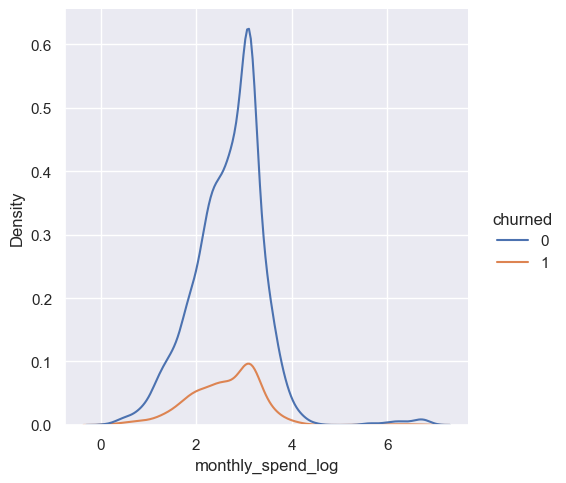

In [101]:
# monthly_spend -> log 변환
# 1. train에서만 subscription_plan별 평균 계산
plan_spend_mean = train.groupby('subscription_plan')['monthly_spend'].mean()

# 2. train에 적용
train['monthly_spend'] = train['monthly_spend'].fillna(
    train['subscription_plan'].map(plan_spend_mean)
)


# 3. test에 적용
test['monthly_spend'] = test['monthly_spend'].fillna(
    test['subscription_plan'].map(plan_spend_mean)
)

train['monthly_spend_log'] = np.log1p(train['monthly_spend'])
test['monthly_spend_log'] = np.log1p(test['monthly_spend'])
sns.displot(data=train, x='monthly_spend_log', hue='churned', kind='kde')

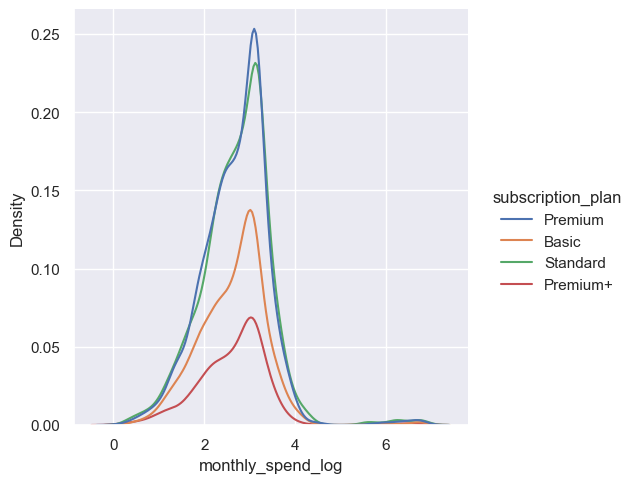

In [102]:
sns.displot(data=train, x='monthly_spend_log', hue='subscription_plan', kind='kde')

In [103]:
train['household_size_missing'] = train['household_size'].isna().astype(int)
test['household_size_missing'] = test['household_size'].isna().astype(int)

train['household_size'] = train['household_size'].fillna(0)
test['household_size'] = test['household_size'].fillna(0)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\386311482.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['household_size_missing'] = train['household_size'].isna().astype(int)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\386311482.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['household_size'] = train['household_size'].fillna(0)


## 인코딩
- 범주형 데이터: gender, country, state_province, subscription_plan, primary_device,

In [104]:
orig_train, orig_test = train.copy(), test.copy()

In [105]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [106]:
# subscription_plan
oe = OrdinalEncoder(categories=[['Basic', 'Standard', 'Premium', 'Premium+']])

train['subscription_plan'] = oe.fit_transform(train[['subscription_plan']])
test['subscription_plan'] = oe.transform(test[['subscription_plan']])

C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\2339728426.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['subscription_plan'] = oe.fit_transform(train[['subscription_plan']])


In [107]:
# 날짜 처리
train['subscription_start_date'] = pd.to_datetime(train['subscription_start_date'])
test['subscription_start_date'] = pd.to_datetime(test['subscription_start_date'])

for df in [train, test]:
    df['start_year'] = df['subscription_start_date'].dt.year
    df['start_month'] = df['subscription_start_date'].dt.month
    df['start_day'] = df['subscription_start_date'].dt.day
    df['start_weekday'] = df['subscription_start_date'].dt.weekday

train = train.drop(columns=['subscription_start_date'])
test = test.drop(columns=['subscription_start_date'])

C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\798199662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['subscription_start_date'] = pd.to_datetime(train['subscription_start_date'])
C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\798199662.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_year'] = df['subscription_start_date'].dt.year
C:\Users\Playdata\AppData\Local\Temp\ipykernel_22188\798199662.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [108]:
# 나머지 범주형 원핫
cat_cols = ['gender', 'country', 'state_province', 'primary_device']

train = pd.get_dummies(train, columns=cat_cols, drop_first=False)
test = pd.get_dummies(test, columns=cat_cols, drop_first=False)

In [109]:
train

,age,subscription_plan,monthly_spend,household_size,churned,monthly_spend_log,household_size_missing,start_year,start_month,start_day,...,state_province_Texas,state_province_Virginia,state_province_Washington,state_province_Wisconsin,primary_device_Desktop,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet
7550,22.0,2.0,10.910000,3.0,0,2.477378,0,2025,3,6,...,False,False,False,False,False,False,False,True,False,False
4916,21.0,0.0,3.850000,3.0,0,1.578979,0,2024,1,23,...,False,False,False,False,False,False,False,False,True,False
5426,34.0,1.0,33.070000,4.0,0,3.528417,0,2024,1,13,...,False,False,False,False,False,False,True,False,False,False
8420,58.0,1.0,5.530000,0.0,0,1.876407,1,2025,7,29,...,False,False,False,False,False,False,False,False,True,False
722,20.0,2.0,26.010000,2.0,0,3.296207,0,2023,10,12,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,31.0,2.0,3.270000,1.0,0,1.451614,0,2023,2,13,...,False,False,False,False,False,False,False,True,False,False
3779,44.0,1.0,12.390000,6.0,0,2.594508,0,2025,5,19,...,False,False,False,False,False,False,False,False,False,True
7618,40.0,1.0,17.250000,1.0,0,2.904165,0,2024,7,3,...,False,False,False,False,False,False,True,False,False,False
9621,25.0,0.0,10.200000,2.0,0,2.415914,0,2024,7,9,...,False,False,False,False,True,False,False,False,False,False


## Baseline Model V0

In [110]:
train.shape, test.shape, test.shape[0] / train.shape[0]

((6769, 52), (1710, 52), 0.2526222484857438)

In [111]:
from sklearn.tree import DecisionTreeClassifier

y_train = train['churned']
X_train = train.drop('churned', axis=1)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


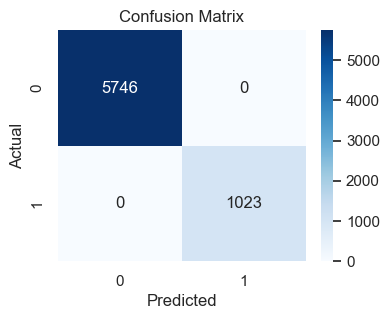

In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

# 예측
y_pred = model.predict(X_train)

# 기본 성능
print("Accuracy:", accuracy_score(y_train, y_pred))
print("Precision:", precision_score(y_train, y_pred))
print("Recall:", recall_score(y_train, y_pred))
print("F1:", f1_score(y_train, y_pred))

cm = confusion_matrix(y_train, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Train ROC-AUC: 1.0


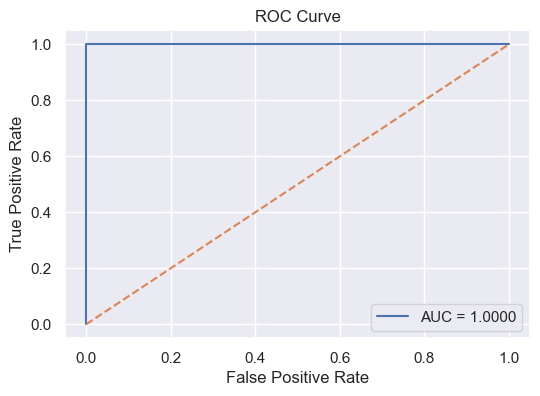

In [113]:
y_pred_proba = model.predict_proba(X_train)[:, 1]

auc = roc_auc_score(y_train, y_pred_proba)
print("Train ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Test Accuracy: 0.7280701754385965
Test F1: 0.143646408839779


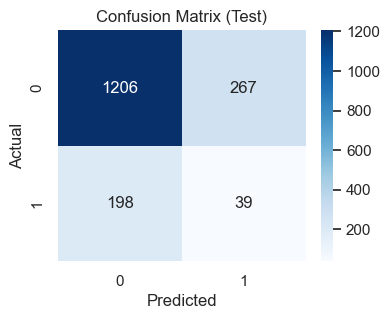

In [114]:
y_test = test['churned']
X_test = test.drop('churned', axis=1)

y_pred_test = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

Test ROC-AUC: 0.4916471164505401


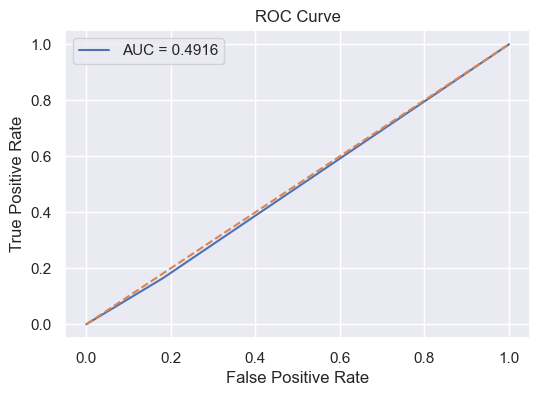

In [115]:
y_test = test['churned']
X_test = test.drop('churned', axis=1)

y_test_proba = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Baseline model v1

### Feature Engineering

In [116]:
orig_train.shape, train.shape

((6769, 12), (6769, 52))